In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("train.csv")
df

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.27,0,0.00,0,53,0,0,32,1000,955,0
1,1,0.00,2,0.00,0,44,0,0,286,2740,533,0
2,1,0.10,2,0.00,0,0,0,1,13,159,98,0
3,1,0.00,1,0.00,0,82,0,0,679,414,651,0
4,1,0.00,2,0.00,0,0,0,1,6,151,126,0
...,...,...,...,...,...,...,...,...,...,...,...,...
571,1,0.55,1,0.44,0,0,0,0,33,166,596,1
572,1,0.38,1,0.33,0,21,0,0,44,66,75,1
573,1,0.57,2,0.00,0,0,0,0,4,96,339,1
574,1,0.57,1,0.00,0,11,0,0,0,57,73,1


In [2]:
data = pd.read_csv("train.csv", usecols=["#followers","#follows","#posts","profile pic","description length","fake"])

In [3]:
data

,profile pic,description length,#posts,#followers,#follows,fake
0,1,53,32,1000,955,0
1,1,44,286,2740,533,0
2,1,0,13,159,98,0
3,1,82,679,414,651,0
4,1,0,6,151,126,0
...,...,...,...,...,...,...
571,1,0,33,166,596,1
572,1,21,44,66,75,1
573,1,0,4,96,339,1
574,1,11,0,57,73,1


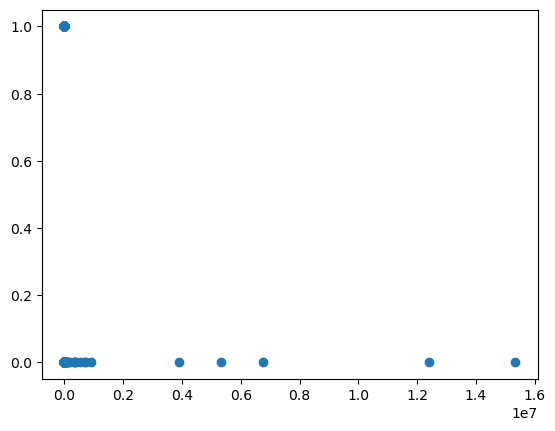

In [4]:
from matplotlib import pyplot as plt
plt.scatter(data["#followers"], data["fake"])

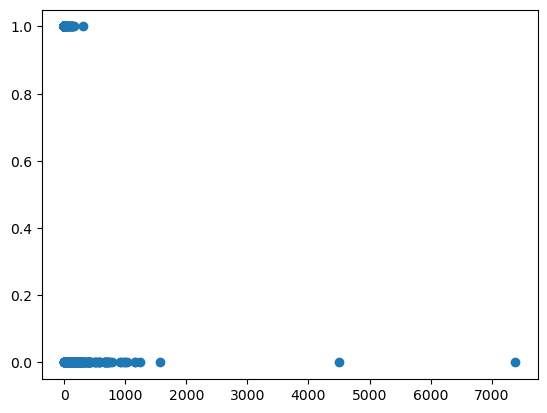

In [5]:
plt.scatter(data["#posts"], data["fake"])

<Axes: xlabel='fake', ylabel='count'>

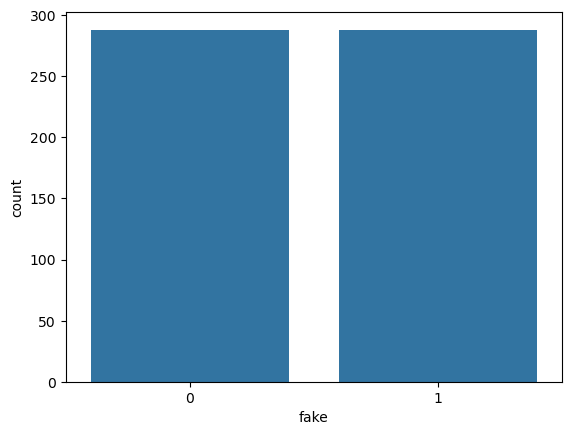

In [6]:
import seaborn as sns
sns.countplot(x='fake', data=df)


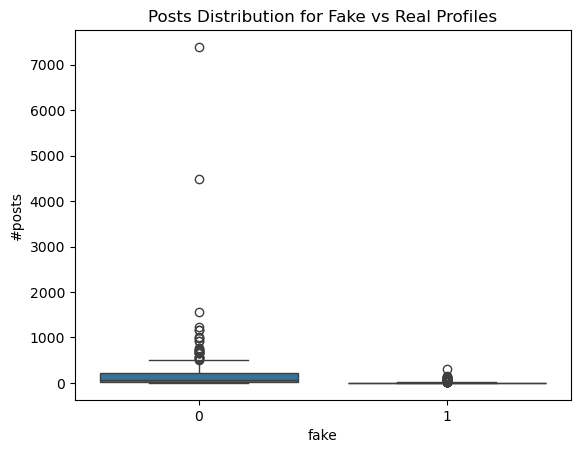

In [7]:
sns.boxplot(x='fake', y='#posts', data=df)
plt.title("Posts Distribution for Fake vs Real Profiles")
plt.show()

In [8]:
X = df[["#followers","#follows","#posts","profile pic","description length"]]
y = df['fake']

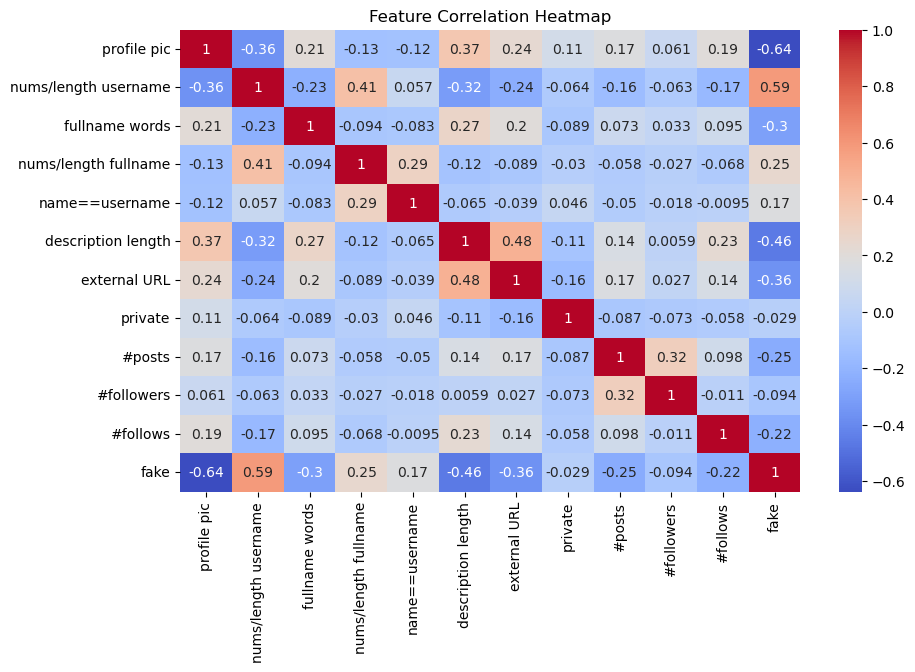

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [10]:
X=data.iloc[:,0:5]

In [11]:
X

,profile pic,description length,#posts,#followers,#follows
0,1,53,32,1000,955
1,1,44,286,2740,533
2,1,0,13,159,98
3,1,82,679,414,651
4,1,0,6,151,126
...,...,...,...,...,...
571,1,0,33,166,596
572,1,21,44,66,75
573,1,0,4,96,339
574,1,11,0,57,73


In [12]:
Y=data.iloc[:,-1]

In [13]:
Y

0      0
1      0
2      0
3      0
4      0
      ..
571    1
572    1
573    1
574    1
575    1
Name: fake, Length: 576, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train, Y_test = train_test_split(X,Y,test_size= 0.1)

In [15]:
X_train

,profile pic,description length,#posts,#followers,#follows
206,1,51,98,1013,996
120,1,0,7,99,132
299,0,0,0,1,34
379,1,5,1,51,420
425,0,0,0,17,44
...,...,...,...,...,...
106,1,122,205,2756,638
334,0,0,0,31,91
37,1,81,50,691,680
86,1,81,101,741,1440


In [16]:
X_test

,profile pic,description length,#posts,#followers,#follows
159,1,0,11,125,101
397,0,0,0,39,40
179,1,0,80,1298,407
487,0,0,2,45,83
404,0,0,0,0,130
87,1,34,157,1267,899
486,0,0,2,34,22
504,0,0,1,16,27
251,1,0,204,139,61
183,1,10,8,791,456


In [17]:
X_test

,profile pic,description length,#posts,#followers,#follows
159,1,0,11,125,101
397,0,0,0,39,40
179,1,0,80,1298,407
487,0,0,2,45,83
404,0,0,0,0,130
87,1,34,157,1267,899
486,0,0,2,34,22
504,0,0,1,16,27
251,1,0,204,139,61
183,1,10,8,791,456


In [18]:
# from sklearn.ensemble import RandomForestClassifier
# model = RandomForestClassifier()
# model.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
# y_pred = model.predict(X_test)

In [20]:
# from sklearn.metrics import accuracy_score
# accuracy = accuracy_score(Y_test, y_pred)
# print("Accuracy = ", accuracy)

Accuracy =  0.8620689655172413


In [22]:
# from sklearn.metrics import confusion_matrix
# print(confusion_matrix(Y_test, y_pred))

[[27  4]
 [ 4 23]]


In [27]:
from xgboost import XGBClassifier
model = XGBClassifier()

model.fit(X_train, Y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [28]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.896551724137931


In [32]:
from sklearn.metrics import precision_score

precision = precision_score(Y_test, y_pred)

print("Precision:", precision)

Precision: 0.8888888888888888


In [33]:
from sklearn.metrics import recall_score

recall = recall_score(Y_test, y_pred)

print("Recall:", recall)

Recall: 0.8888888888888888


In [39]:
import pickle
pickle.dump(model, open("fake_profile_model.pkl", "wb"))